# Unsupervised Learning 
## Mall Customer Segmentation
  
**Algorithms:** K-Means Clustering, Agglomerative Hierarchical Clustering, DBSCAN  
**Dataset:** Mall Customer Segmentation Dataset — 200 customer records

### Project Objective
Use unsupervised learning to discover meaningful customer segments from demographic and spending behaviour features, compare three clustering algorithms, and translate the clusters into business insights.

> **Notebook note:**The primary clustering features are standardized `Annual_Income` and `Spending_Score`, while `Age` is also scaled and retained for cluster profiling.


# Task  — Imports and notebook setup

In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
   
)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'axes.facecolor': '#FCFCFC',
    'figure.facecolor': 'white',
    'axes.edgecolor': '#D9DDE2',
    'axes.linewidth': 0.8,
    'grid.color': '#E9ECEF',
    'grid.linewidth': 0.6,
    'grid.alpha': 0.8,
    'axes.titleweight': 'semibold',
})
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
DATA_PATH = "Mall_Customers.csv"

print("Libraries imported successfully.")


Libraries imported successfully.


# Task 1 — Data Loading & Exploratory Data Analysis (EDA)

**Objective:** Load the Mall Customers dataset, inspect its structure, clean the column names, encode Gender, and understand feature distributions and relationships.

**Expected output:** Dataset inspection, histograms with KDE, pairplot, correlation heatmap, and EDA observations.


In [5]:
# 1.1 Load the dataset
df_raw = pd.read_csv("../Dataset/Mall_Customers.csv")


print("First 5 rows:")
display(df_raw.head())

print("\nDataset information:")
df_raw.info()

print("\nDescriptive statistics:")
display(df_raw.describe())

print(f"\nShape: {df_raw.shape}")
print(f"Total null values: {df_raw.isnull().sum().sum()}")
print(f"Total duplicate rows: {df_raw.duplicated().sum()}")


First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Descriptive statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000



Shape: (200, 5)
Total null values: 0
Total duplicate rows: 0


In [6]:
# 1.2 Rename columns and drop CustomerID
df = df_raw.rename(columns={
    "Annual Income (k$)": "Annual_Income",
    "Spending Score (1-100)": "Spending_Score"
}).copy()

df = df.drop(columns=["CustomerID"])

print("Columns after preprocessing:")
print(df.columns.tolist())
display(df.head())


Columns after preprocessing:
['Gender', 'Age', 'Annual_Income', 'Spending_Score']


,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [7]:
# 1.3 Encode Gender using LabelEncoder
label_encoder = LabelEncoder()
df["Gender"] = label_encoder.fit_transform(df["Gender"])

gender_mapping = dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
))

print("Gender encoding:", gender_mapping)
display(df.head())


Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}


,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


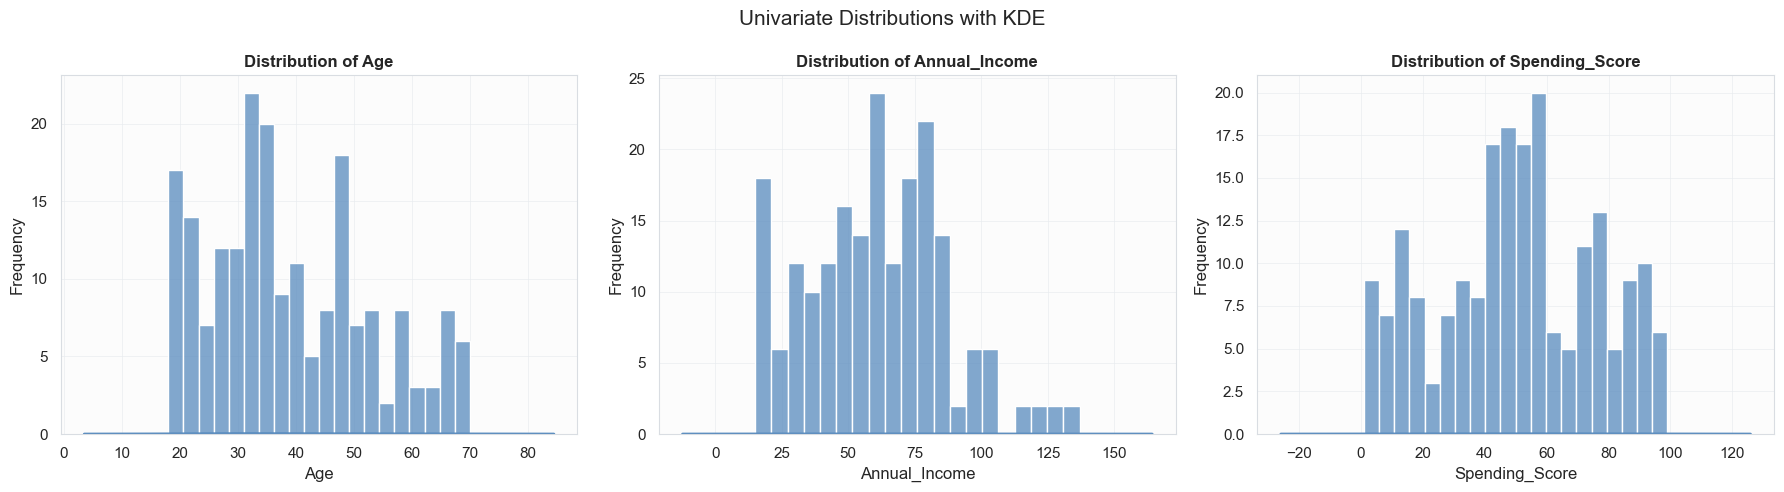

In [8]:
# 1.4 Univariate distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ["Age", "Annual_Income", "Spending_Score"]

for ax, feature in zip(axes, features):
    sns.histplot(df[feature], kde=False, bins=20, ax=ax, color="#588BBE")
    sns.kdeplot(df[feature], ax=ax, linewidth=2, color="#588BBE")
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.suptitle("Univariate Distributions with KDE", fontsize=15)
plt.tight_layout()
plt.show()


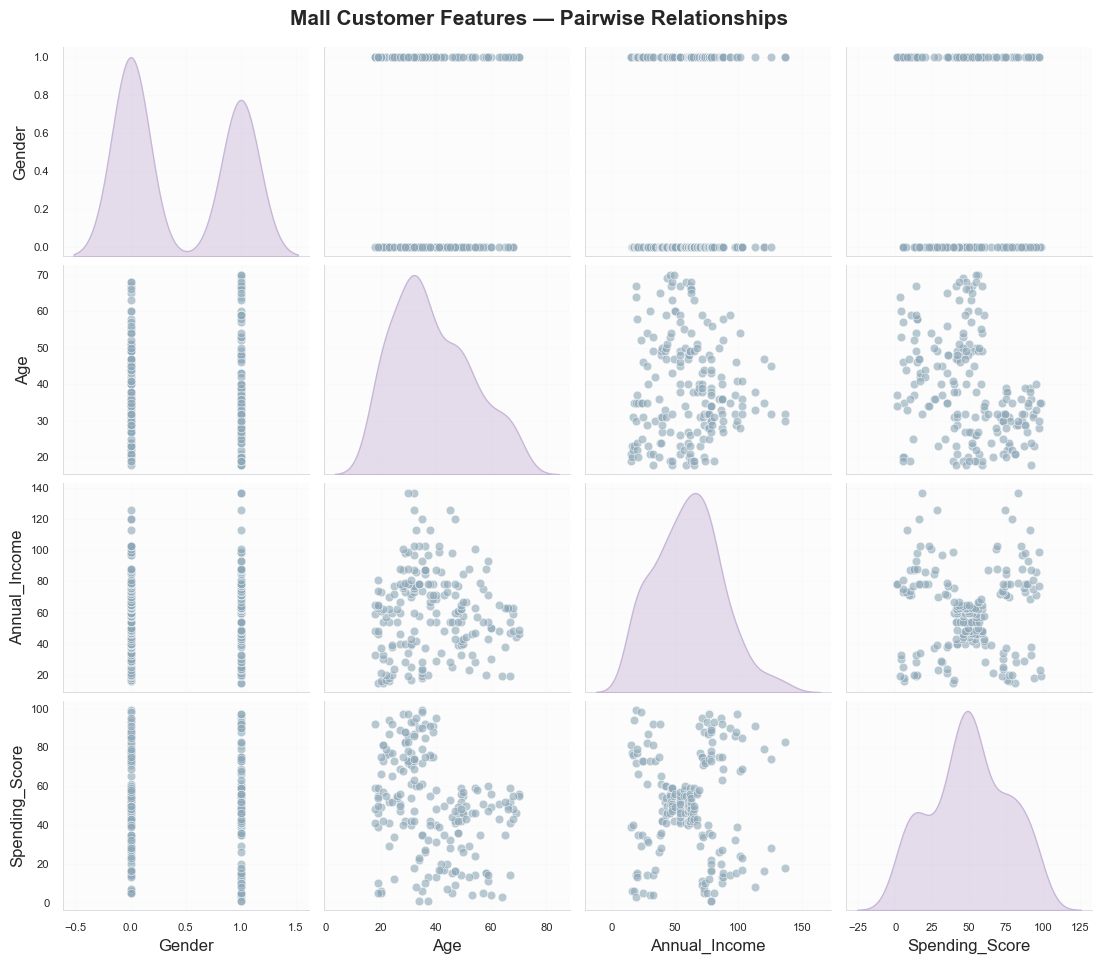

In [9]:
# Professional minimal pairplot
pairplot_data = df[['Gender', 'Age', 'Annual_Income', 'Spending_Score']].copy()

g = sns.pairplot(
    pairplot_data,
    hue=None,
    diag_kind='kde',
    corner=False,
    height=2.25,
    aspect=1.0,
    plot_kws={
        's': 38,
        'alpha': 0.62,
        'color': '#8FA8B8',
        'edgecolor': 'white',
        'linewidth': 0.5
    },
    diag_kws={
        'color': '#C8B6D8',
        'fill': True,
        'alpha': 0.45,
        'linewidth': 1
    }
)

g.fig.set_size_inches(11.5, 9.5)
g.fig.suptitle(
    'Mall Customer Features — Pairwise Relationships',
    fontsize=15,
    fontweight='semibold',
    y=1.02
)

for ax in g.axes.flatten():
    if ax is not None:
        ax.set_facecolor('#FCFCFC')
        ax.grid(True, linewidth=0.5, alpha=0.25)
        ax.tick_params(labelsize=8)
        for spine in ax.spines.values():
            spine.set_linewidth(0.7)
            spine.set_color('#D9DDE2')

plt.show()


### 1.6 EDA Summary

- The dataset contains **200 customer records** and the original five columns contain no missing values or duplicate rows.
- `Age`, `Annual_Income`, and `Spending_Score` have different distributions, so their raw scales should not be used directly for distance-based clustering.
- The **Annual Income vs Spending Score** pair is visually useful because it separates customers according to two business-relevant dimensions: purchasing capacity and observed spending behaviour.
- The pairplot provides visible group structure, especially in the income–spending relationship, which motivates the two-feature clustering analysis.
- Correlation values should be interpreted as relationships between individual variables; clustering will instead use distances between customer observations.


# Task 2 — Feature Scaling & Feature Selection

**Objective:** Standardize the numerical features and create the required two-feature dataset for the primary clustering tasks.

**Expected output:** `df_scaled` containing scaled Age, Annual_Income and Spending_Score, plus `df_2f` containing the two primary clustering features.


In [10]:
# 2.1 Scale Age, Annual_Income and Spending_Score
scaler = StandardScaler()

df_scaled = df.copy()
numeric_features = ["Age", "Annual_Income", "Spending_Score"]

df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])

print("Scaled feature means (approximately 0):")
display(df_scaled[numeric_features].mean().to_frame("Mean"))

print("Scaled feature standard deviations (approximately 1):")
display(df_scaled[numeric_features].std(ddof=0).to_frame("Std"))


Scaled feature means (approximately 0):


,Mean
Age,-1.021405e-16
Annual_Income,-2.131628e-16
Spending_Score,-1.465494e-16


Scaled feature standard deviations (approximately 1):


,Std
Age,1.0
Annual_Income,1.0
Spending_Score,1.0


In [11]:
# 2.2 Select the required 2-feature subset
df_2f = df_scaled[["Annual_Income", "Spending_Score"]].copy()

print("df_2f shape:", df_2f.shape)
display(df_2f.head())


df_2f shape: (200, 2)


,Annual_Income,Spending_Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


### 2.3 Why StandardScaler is required

StandardScaler transforms each numerical feature so that its mean is approximately 0 and its standard deviation is approximately 1.

This matters because **K-Means, DBSCAN, and hierarchical clustering use distances**. If features remain on different scales, a feature with a larger numerical range can contribute disproportionately to distance calculations. Scaling places Age, Annual Income, and Spending Score on a comparable scale.

The PR therefore requires scaling before clustering, while `Gender` is kept as a binary encoded feature and is not scaled.


# Task 3 — K-Means Clustering

**Objective:** Determine a suitable number of clusters using the Elbow Method and Silhouette Score, fit the final K-Means model, visualize clusters, and profile each segment.

**Expected output:** Elbow plot, silhouette plot, final 5-cluster model, centroid visualization, profile table, and business segment names.


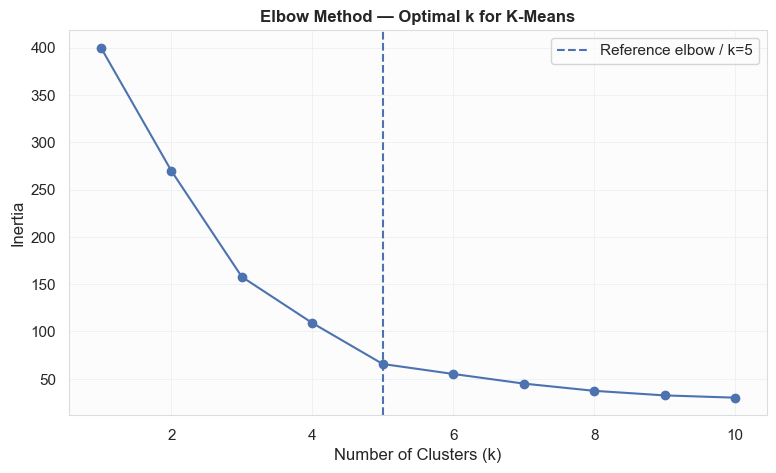

,k,Inertia
0,1,400.000000
1,2,269.691012
2,3,157.704008
3,4,108.921317
4,5,65.568408
5,6,55.057348
6,7,44.864756
7,8,37.228188
8,9,32.392268
9,10,29.981898


In [12]:
# 3.1 Elbow Method
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(df_2f)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_values, inertias, marker="o")
plt.axvline(5, linestyle="--", label="Reference elbow / k=5")
plt.title("Elbow Method — Optimal k for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.legend()
plt.show()

elbow_table = pd.DataFrame({"k": list(k_values), "Inertia": inertias})
display(elbow_table)


**Interpretation:** Inertia measures the within-cluster sum of squared distances to the cluster centroids. As `k` increases, inertia decreases because the model has more centroids. The useful region is where adding another cluster produces a smaller practical improvement. For this dataset, **k = 5** gives the classic customer-segmentation structure requested by the PR.


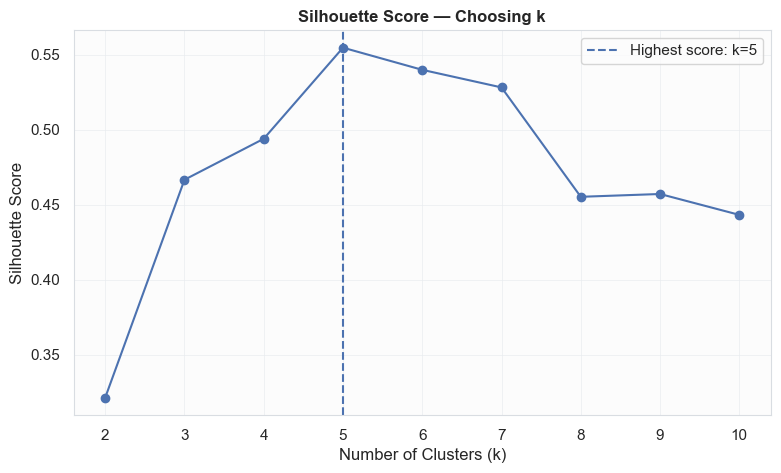

,k,Silhouette Score
0,2,0.321271
1,3,0.466585
2,4,0.493907
3,5,0.554657
4,6,0.539880
5,7,0.528149
6,8,0.455215
7,9,0.457085
8,10,0.443171


Data-driven optimum from Silhouette Score: k = 5


In [13]:
# 3.2 Silhouette Score
silhouette_values = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(df_2f)
    silhouette_values.append(silhouette_score(df_2f, labels))

best_k = int(np.argmax(silhouette_values) + 2)

plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), silhouette_values, marker="o")
plt.axvline(best_k, linestyle="--", label=f"Highest score: k={best_k}")
plt.title("Silhouette Score — Choosing k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.show()

silhouette_table = pd.DataFrame({
    "k": range(2, 11),
    "Silhouette Score": silhouette_values
})
display(silhouette_table)

print(f"Data-driven optimum from Silhouette Score: k = {best_k}")


### Elbow vs Silhouette

The Elbow Method and Silhouette Score answer related but different questions. The elbow looks for diminishing returns in within-cluster inertia, while the silhouette measures how well-separated and internally cohesive the clusters are.

For this dataset, the highest silhouette score occurs at **k = 5 (≈ 0.555)**, and this also aligns with the PR brief's typical `k=5` choice. Therefore, the final K-Means model uses **5 clusters**.


In [14]:
# 3.3 Fit final K-Means model
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)

df["KMeans_Cluster"] = kmeans_final.fit_predict(df_2f)

print("K-Means cluster counts:")
display(df["KMeans_Cluster"].value_counts().sort_index())


K-Means cluster counts:


KMeans_Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

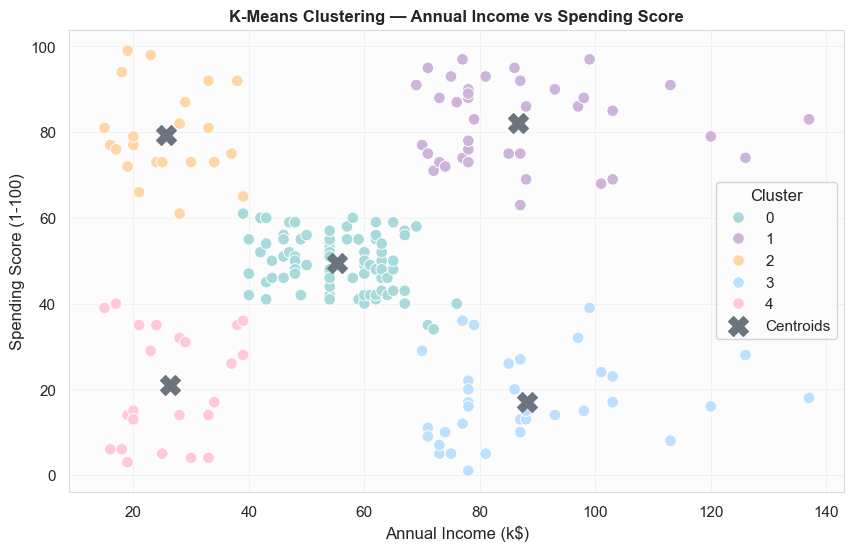

In [15]:
# 3.4 Visualize K-Means clusters and centroids
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="KMeans_Cluster",
    data=df,
    palette=['#A8DADC','#CDB4DB','#FFD6A5','#BDE0FE','#FFC8DD','#CAFFBF','#FFADAD','#FDFFB6','#9BF6FF','#BDB2FF'],
    s=70
)

# Centroids are in the standardized feature space, so transform them
# back to the original income/spending units for plotting against df.
centroids_original = scaler.inverse_transform(
    np.column_stack([
        np.zeros(best_k),  # placeholder for Age because only 2 centroid features are used
        kmeans_final.cluster_centers_[:, 0],
        kmeans_final.cluster_centers_[:, 1]
    ])
)[:, 1:]

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    c="#6C757D",
    marker="X",
    s=200,
    label="Centroids"
)

plt.title("K-Means Clustering — Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()


In [16]:
# 3.5 K-Means cluster profile table
kmeans_profile = (
    df.groupby("KMeans_Cluster")[["Age", "Annual_Income", "Spending_Score"]]
    .mean()
    .round(2)
)

kmeans_segment_names = {
    0: "Average Income, Average Spenders",
    1: "High Income, High Spenders",
    2: "Low Income, High Spenders",
    3: "High Income, Low Spenders",
    4: "Low Income, Low Spenders"
}

kmeans_profile["Segment"] = kmeans_profile.index.map(kmeans_segment_names)

kmeans_profile = kmeans_profile[
    ["Segment", "Age", "Annual_Income", "Spending_Score"]
]

display(
    kmeans_profile.style
    .format({
        "Age": "{:.1f}",
        "Annual_Income": "{:.1f}",
        "Spending_Score": "{:.1f}"
    })
)


,Segment,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,,
0,"Average Income, Average Spenders",42.7,55.3,49.5
1,"High Income, High Spenders",32.7,86.5,82.1
2,"Low Income, High Spenders",25.3,25.7,79.4
3,"High Income, Low Spenders",41.1,88.2,17.1
4,"Low Income, Low Spenders",45.2,26.3,20.9


### K-Means Business Interpretation

| Segment | Meaning | Possible marketing action |
|---|---|---|
| Average Income, Average Spenders | Mainstream customers with moderate income and spending | Broad loyalty offers and personalized product bundles |
| High Income, High Spenders | Customers with strong income and high mall spending | Premium loyalty rewards and exclusive offers |
| Low Income, High Spenders | Lower-income customers who still spend heavily | Value bundles, limited-time promotions, and loyalty incentives |
| High Income, Low Spenders | Customers with purchasing capacity but relatively low mall spending | Targeted engagement, premium product discovery, and personalized offers |
| Low Income, Low Spenders | Lower-income and lower-spending customers | Budget promotions, entry-level offers, and discount campaigns |

These are **descriptive segment interpretations**, not causal conclusions: the dataset contains demographic and mall spending-score information, not detailed purchase histories.


# Task 4 — Agglomerative Hierarchical Clustering

**Objective:** Use Ward-linkage hierarchical clustering to understand the nested structure of customers, select a dendrogram cut, fit the model, and compare it with K-Means.

**Expected output:** Dendrogram with cut line, hierarchical cluster scatter plot, K-Means vs Hierarchical comparison, and profile table.


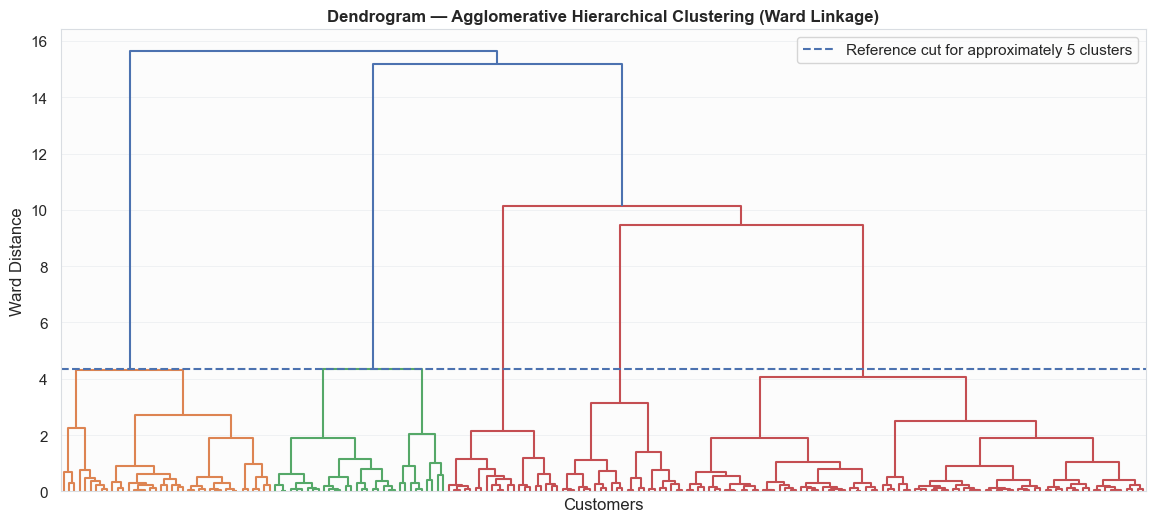

In [17]:
# 4.1 Dendrogram using Ward linkage
linkage_matrix = linkage(df_2f, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, no_labels=True, color_threshold=None)
plt.axhline(
    y=linkage_matrix[-5, 2],
    linestyle="--",
    label="Reference cut for approximately 5 clusters"
)
plt.title("Dendrogram — Agglomerative Hierarchical Clustering (Ward Linkage)")
plt.xlabel("Customers")
plt.ylabel("Ward Distance")
plt.legend()
plt.show()


### How to read the dendrogram

Ward linkage joins clusters while trying to minimize the increase in within-cluster variance. The vertical height of a merge represents the dissimilarity at which groups are joined.

A horizontal cut through the dendrogram determines the number of clusters. A cut around the larger vertical separation in this dataset supports a **5-cluster** solution, matching the K-Means analysis.


In [18]:
# 4.2 Fit Agglomerative Hierarchical model
hierarchical = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

df["Hier_Cluster"] = hierarchical.fit_predict(df_2f)

print("Hierarchical cluster counts:")
display(df["Hier_Cluster"].value_counts().sort_index())


Hierarchical cluster counts:


Hier_Cluster
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64

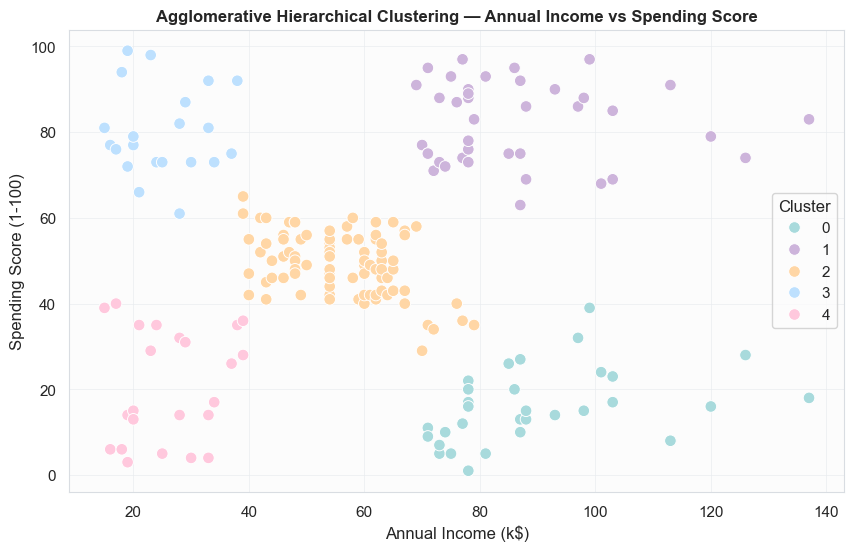

In [19]:
# 4.3 Visualize hierarchical clusters
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="Hier_Cluster",
    data=df,
    palette=['#A8DADC','#CDB4DB','#FFD6A5','#BDE0FE','#FFC8DD','#CAFFBF','#FFADAD','#FDFFB6','#9BF6FF','#BDB2FF'],
    s=70
)

plt.title("Agglomerative Hierarchical Clustering — Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()


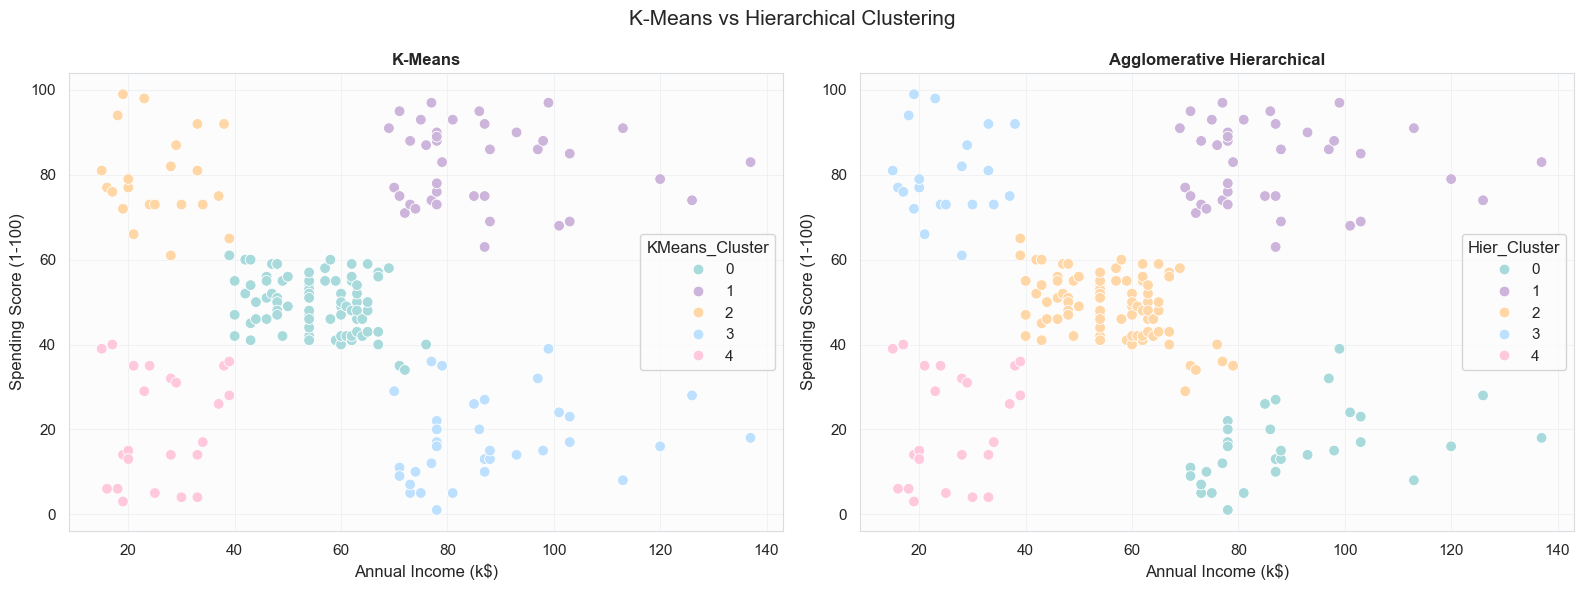

In [20]:
# 4.4 Side-by-side comparison with K-Means
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="KMeans_Cluster",
    data=df,
    palette=['#A8DADC','#CDB4DB','#FFD6A5','#BDE0FE','#FFC8DD','#CAFFBF','#FFADAD','#FDFFB6','#9BF6FF','#BDB2FF'],
    s=60,
    ax=axes[0]
)
axes[0].set_title("K-Means")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score (1-100)")

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="Hier_Cluster",
    data=df,
    palette=['#A8DADC','#CDB4DB','#FFD6A5','#BDE0FE','#FFC8DD','#CAFFBF','#FFADAD','#FDFFB6','#9BF6FF','#BDB2FF'],
    s=60,
    ax=axes[1]
)
axes[1].set_title("Agglomerative Hierarchical")
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Spending Score (1-100)")

plt.suptitle("K-Means vs Hierarchical Clustering", fontsize=15)
plt.tight_layout()
plt.show()


### K-Means vs Hierarchical interpretation

The two methods produce very similar broad customer structure because both are clustering the same standardized income–spending space into five groups.

- **K-Means** is centroid-based: each observation is assigned according to its distance from cluster centroids.
- **Hierarchical clustering** is connectivity-based: observations are progressively merged into a tree structure.
- Border-region customers can receive different labels because the algorithms define cluster membership differently.
- The numerical cluster labels themselves are not meaningful across algorithms; the profile means and spatial positions should be compared instead.


In [21]:
# 4.5 Hierarchical cluster profile table
hier_profile = (
    df.groupby("Hier_Cluster")[["Age", "Annual_Income", "Spending_Score"]]
    .mean()
    .round(2)
)

display(hier_profile)

print("K-Means profile:")
display(kmeans_profile)

print("Observation: the hierarchical profiles closely reproduce the five broad income/spending segments.")


,Age,Annual_Income,Spending_Score
Hier_Cluster,,,
0,41.00,89.41,15.59
1,32.69,86.54,82.13
2,42.48,55.81,49.13
3,25.33,25.10,80.05
4,45.22,26.30,20.91


K-Means profile:


,Segment,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,,
0,"Average Income, Average Spenders",42.72,55.30,49.52
1,"High Income, High Spenders",32.69,86.54,82.13
2,"Low Income, High Spenders",25.27,25.73,79.36
3,"High Income, Low Spenders",41.11,88.20,17.11
4,"Low Income, Low Spenders",45.22,26.30,20.91


Observation: the hierarchical profiles closely reproduce the five broad income/spending segments.


# Task 5 — DBSCAN Clustering

**Objective:** Estimate `eps`, tune `eps` and `min_samples`, fit DBSCAN, identify noise points, and compare density-based clustering with K-Means.

**Expected output:** 4-NN k-distance plot, parameter grid-search table, final DBSCAN scatter plot, and conceptual comparison.


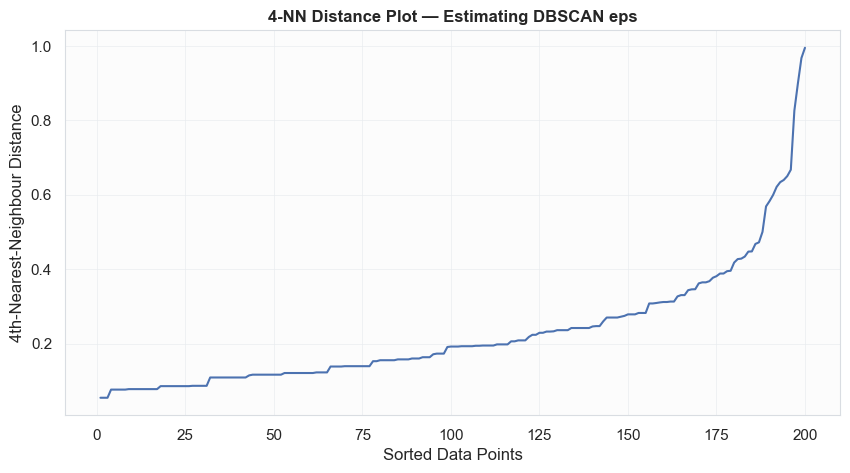

In [22]:
# 5.1 4-NN k-distance plot
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(df_2f)

distances, indices = neighbors_fit.kneighbors(df_2f)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(k_distances) + 1), k_distances)
plt.title("4-NN Distance Plot — Estimating DBSCAN eps")
plt.xlabel("Sorted Data Points")
plt.ylabel("4th-Nearest-Neighbour Distance")
plt.show()


The k-distance plot helps identify a region where distances begin rising sharply. That transition is a practical starting point for choosing `eps`. The final value should also be checked against cluster count and noise level rather than selected from the plot alone.


In [23]:
# 5.2 Grid search over eps and min_samples
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3, 4, 5, 6]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(df_2f)

        non_noise_mask = labels != -1
        non_noise_labels = labels[non_noise_mask]

        n_clusters = len(set(non_noise_labels))
        noise_points = int((labels == -1).sum())

        if n_clusters >= 2:
            sil = silhouette_score(
                df_2f.loc[non_noise_mask],
                non_noise_labels
            )
        else:
            sil = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_points": noise_points,
            "silhouette_score": sil
        })

dbscan_grid = pd.DataFrame(dbscan_results)

display(
    dbscan_grid.style
    .format({"silhouette_score": "{:.3f}"})
    .background_gradient(subset=["silhouette_score"], cmap="Blues")
)


,eps,min_samples,n_clusters,noise_points,silhouette_score
0,0.200000,3,13,44,0.470
1,0.200000,4,5,73,0.617
2,0.200000,5,7,77,0.586
3,0.200000,6,4,95,0.614
4,0.300000,3,9,14,0.472
5,0.300000,4,8,23,0.520
6,0.300000,5,7,35,0.524
7,0.300000,6,6,48,0.530
8,0.400000,3,4,10,0.395
9,0.400000,4,3,14,0.458


### DBSCAN parameter choice

The grid shows an important trade-off. Very small `eps` values can produce a high silhouette score among the retained points but label a large fraction of customers as noise.

For the final model, **`eps = 0.4` and `min_samples = 5`** are used as a balanced setting: they produce **4 clusters with 15 noise points**, while avoiding the very large noise fractions produced by the tightest settings.

This is deliberately different from simply choosing the maximum silhouette value, because the PR asks for coherent clusters with minimal noise.


In [24]:
# 5.3 Fit final DBSCAN model
final_eps = 0.4
final_min_samples = 5

dbscan_final = DBSCAN(
    eps=final_eps,
    min_samples=final_min_samples
)

df["DBSCAN_Cluster"] = dbscan_final.fit_predict(df_2f)

print(f"Final DBSCAN parameters: eps={final_eps}, min_samples={final_min_samples}")
print(f"Noise points: {(df['DBSCAN_Cluster'] == -1).sum()}")
print("Cluster counts including noise:")
display(df["DBSCAN_Cluster"].value_counts().sort_index())


Final DBSCAN parameters: eps=0.4, min_samples=5
Noise points: 15
Cluster counts including noise:


DBSCAN_Cluster
-1     15
 0    115
 1     11
 2     32
 3     27
Name: count, dtype: int64

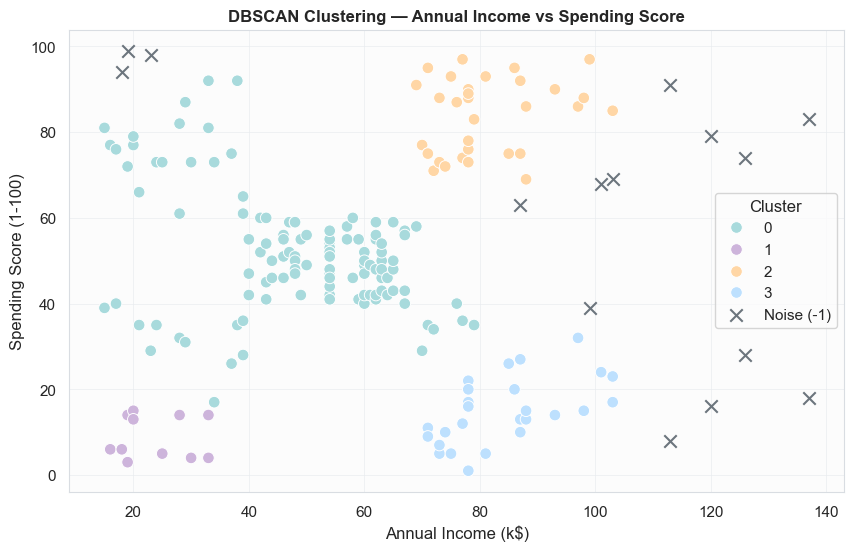

In [25]:
# 5.4 Visualize DBSCAN clusters and noise
plt.figure(figsize=(10, 6))

cluster_mask = df["DBSCAN_Cluster"] != -1
noise_mask = ~cluster_mask

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="DBSCAN_Cluster",
    data=df[cluster_mask],
    palette=['#A8DADC','#CDB4DB','#FFD6A5','#BDE0FE','#FFC8DD','#CAFFBF','#FFADAD','#FDFFB6','#9BF6FF','#BDB2FF'],
    s=70
)

if noise_mask.any():
    plt.scatter(
        df.loc[noise_mask, "Annual_Income"],
        df.loc[noise_mask, "Spending_Score"],
        c="#6C757D",
        marker="x",
        s=80,
        label="Noise (-1)"
    )

plt.title("DBSCAN Clustering — Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()


### 5.5 DBSCAN vs K-Means — Shape Detection

1. **Number of clusters:** DBSCAN does not require `k` to be specified in advance; it discovers dense regions.
2. **Cluster shape:** DBSCAN can detect non-spherical shapes, while K-Means is based on distances to centroids and tends to form compact centroid-based groups.
3. **Noise:** DBSCAN can explicitly label low-density observations as `-1`; K-Means assigns every observation to a cluster.
4. **Parameter sensitivity:** DBSCAN depends strongly on `eps` and `min_samples`; inappropriate values can create too much noise or merge separate groups.
5. **This dataset:** K-Means and Hierarchical both produce five broad segments, while the selected DBSCAN configuration produces four dense clusters plus noise. This difference reflects the algorithms' different assumptions rather than a simple one-to-one label correspondence.


# Task 6 — Algorithm Comparison & Business Insights

**Objective:** Compare all three clustering algorithms visually and numerically, test the optional all-feature extension, and translate the most interpretable customer segmentation into business actions.

**Expected output:** Three-panel comparison, metrics table, all-feature extension, and structured business insight report.


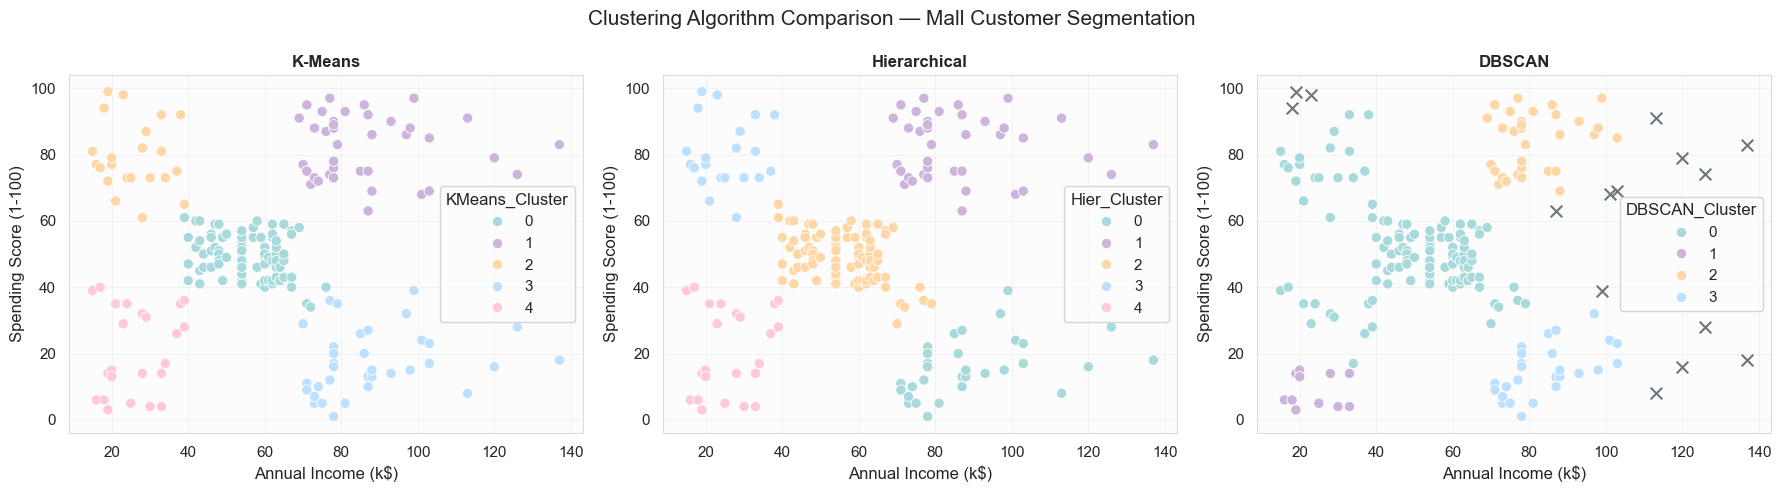

In [26]:
# 6.1 Three-panel comparison figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    x="Annual_Income", y="Spending_Score",
    hue="KMeans_Cluster", data=df,
    palette=['#A8DADC','#CDB4DB','#FFD6A5','#BDE0FE','#FFC8DD','#CAFFBF','#FFADAD','#FDFFB6','#9BF6FF','#BDB2FF'], s=55, ax=axes[0]
)
axes[0].set_title("K-Means")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score (1-100)")

sns.scatterplot(
    x="Annual_Income", y="Spending_Score",
    hue="Hier_Cluster", data=df,
    palette=['#A8DADC','#CDB4DB','#FFD6A5','#BDE0FE','#FFC8DD','#CAFFBF','#FFADAD','#FDFFB6','#9BF6FF','#BDB2FF'], s=55, ax=axes[1]
)
axes[1].set_title("Hierarchical")
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Spending Score (1-100)")

non_noise = df["DBSCAN_Cluster"] != -1
sns.scatterplot(
    x="Annual_Income", y="Spending_Score",
    hue="DBSCAN_Cluster", data=df[non_noise],
    palette=['#A8DADC','#CDB4DB','#FFD6A5','#BDE0FE','#FFC8DD','#CAFFBF','#FFADAD','#FDFFB6','#9BF6FF','#BDB2FF'], s=55, ax=axes[2]
)
if (~non_noise).any():
    axes[2].scatter(
        df.loc[~non_noise, "Annual_Income"],
        df.loc[~non_noise, "Spending_Score"],
        c="#6C757D", marker="x", s=70, label="Noise"
    )
axes[2].set_title("DBSCAN")
axes[2].set_xlabel("Annual Income (k$)")
axes[2].set_ylabel("Spending Score (1-100)")

fig.suptitle("Clustering Algorithm Comparison — Mall Customer Segmentation", fontsize=15)
plt.tight_layout()
plt.show()


In [30]:
# 6.2 Metrics summary — Silhouette, Davies-Bouldin and Calinski-Harabasz
def calculate_metrics(labels, X, exclude_noise=False):
    mask = np.ones(len(labels), dtype=bool)

    if exclude_noise:
        mask = labels != -1

    X_eval = X.loc[mask]
    y_eval = np.asarray(labels)[mask]

    n_clusters = len(np.unique(y_eval))

    return {
        "n_clusters": n_clusters,
        "Silhouette Score": silhouette_score(X_eval, y_eval)
    }

metrics_summary = pd.DataFrame([
    {"Algorithm": "K-Means", **calculate_metrics(df["KMeans_Cluster"], df_2f)},
    {"Algorithm": "Hierarchical", **calculate_metrics(df["Hier_Cluster"], df_2f)},
    {"Algorithm": "DBSCAN", **calculate_metrics(df["DBSCAN_Cluster"], df_2f, exclude_noise=True)}
])

display(
    metrics_summary.style.format({
        "Silhouette Score": "{:.3f}",
        "Davies-Bouldin Index": "{:.3f}",
        "Calinski-Harabasz Index": "{:.2f}"
    })
)


,Algorithm,n_clusters,Silhouette Score
0,K-Means,5,0.555
1,Hierarchical,5,0.554
2,DBSCAN,4,0.478


### Metrics interpretation

For **Silhouette Score**, higher is better because it indicates stronger separation and cohesion. For **Davies-Bouldin Index**, lower is better because it indicates less similarity between clusters. For **Calinski-Harabasz Index**, higher generally indicates better separation relative to within-cluster dispersion.

On this dataset, K-Means and Hierarchical have very similar metrics because their five broad partitions are similar. DBSCAN's metrics are calculated after excluding its noise points, as required by the PR; therefore its metric values should not be compared as though the evaluation population were identical. For practical deployment, the algorithm choice should also consider interpretability and whether density/noise detection is required.


In [28]:
# 6.2 Extension — Test clustering using all four preprocessed features
# This follows the PR note that using all four features is valid and should be tested as an extension.
all_features = ["Gender", "Age", "Annual_Income", "Spending_Score"]

all_feature_scaler = StandardScaler()
X_all = pd.DataFrame(
    all_feature_scaler.fit_transform(df[all_features]),
    columns=all_features,
    index=df.index
)

all_feature_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_all)
    all_feature_scores.append({
        "k": k,
        "Silhouette Score": silhouette_score(X_all, labels)
    })

all_feature_scores = pd.DataFrame(all_feature_scores)

display(all_feature_scores)

best_all_k = int(
    all_feature_scores.loc[
        all_feature_scores["Silhouette Score"].idxmax(), "k"
    ]
)

print(f"Best silhouette k using all four features: {best_all_k}")


,k,Silhouette Score
0,2,0.251815
1,3,0.259513
2,4,0.298397
3,5,0.304060
4,6,0.331074
5,7,0.357377
6,8,0.387993
7,9,0.403092
8,10,0.420764


Best silhouette k using all four features: 10


### Extension interpretation

The primary PR workflow intentionally uses `Annual_Income` and `Spending_Score` because they are easy to visualize in two dimensions. The all-feature experiment checks whether including encoded Gender and Age changes the data-driven cluster structure.

The two-feature solution remains the primary presentation because it directly supports the required scatter plots and business interpretation.


## Business Insights for Mall Management

### K-Means segments and suggested actions

**1. Average Income, Average Spenders**  
These customers represent a mainstream group with moderate income and spending.  
**Action:** Use broad loyalty benefits, product bundles, and personalized offers to increase repeat visits.

**2. High Income, High Spenders**  
These customers combine higher income with high spending scores.  
**Action:** Offer premium loyalty rewards, early access, and exclusive shopping experiences.

**3. Low Income, High Spenders**  
These customers have lower income but relatively high mall spending.  
**Action:** Use value-oriented bundles and limited-time promotions while encouraging continued loyalty.

**4. High Income, Low Spenders**  
These customers have high income but relatively low spending scores.  
**Action:** Test personalized product discovery, premium-category recommendations, and targeted engagement campaigns.

**5. Low Income, Low Spenders**  
These customers have both lower income and lower spending scores.  
**Action:** Focus on affordable offers, entry-level promotions, and discounts that encourage additional visits.

### Deployment consideration

For a conventional mall customer-segmentation workflow, **K-Means is highly interpretable** because each segment can be described through a centroid/profile and the required number of segments is explicit. DBSCAN is particularly useful when the business needs density-based grouping and explicit noise detection. Hierarchical clustering is useful when management wants to inspect a hierarchy of customer relationships through a dendrogram.

The appropriate production choice should ultimately be validated with business goals, new customer data, stability checks, and campaign outcomes.


In [29]:
# Final output: save the clustered dataset for optional inspection
output_columns = [
    "Gender", "Age", "Annual_Income", "Spending_Score",
    "KMeans_Cluster", "Hier_Cluster", "DBSCAN_Cluster"
]

clustered_output = df[output_columns].copy()
clustered_output.to_csv("Mall_Customers_Clustered.csv", index=False)

print("Saved: Mall_Customers_Clustered.csv")
display(clustered_output.head())


Saved: Mall_Customers_Clustered.csv


,Gender,Age,Annual_Income,Spending_Score,KMeans_Cluster,Hier_Cluster,DBSCAN_Cluster
0,1,19,15,39,4,4,0
1,1,21,15,81,2,3,0
2,0,20,16,6,4,4,1
3,0,23,16,77,2,3,0
4,0,31,17,40,4,4,0
